<a href="https://colab.research.google.com/github/rodrigovaleferreira/FIAP_atividades/blob/main/atividade_fiap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [74]:
!pip install catboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from catboost import CatBoostClassifier
from sklearn.metrics import RocCurveDisplay

In [75]:
df = pd.read_csv('/content/payflow_credit_risk.csv')
df.head()

,id_cliente,idade,renda_mensal,tempo_emprego_anos,autonomo,score_credito,valor_solicitado,prazo_meses,juros_mensal_pct,qtde_cartoes,...,dias_atraso_max_12m,reclamacoes_6m,possui_avalista,canal_aquisicao,regiao,tipo_produto,parcelas_pagas_ate_3m,atraso_primeira_parcela_dias,status_apos_90d,default_90d
0,1,22,2639.75,2.718888,0,617.0,2619.14,12,3.96,3,...,0,0,0,site,Sul,emprestimo_pessoal,0,29,default,1
1,2,59,2482.34,10.785992,0,619.0,9101.21,36,3.37,2,...,0,0,0,app,Sudeste,cartao,2,10,em_dia,0
2,3,52,6230.69,9.547608,0,665.0,13258.67,48,3.12,0,...,0,0,0,loja,Sudeste,cartao,2,0,em_dia,0
3,4,41,6469.45,4.287084,0,676.0,1407.28,12,1.52,2,...,90,1,0,parceiro,Sudeste,emprestimo_pessoal,3,0,em_dia,0
4,5,40,2343.04,0.000000,0,671.0,2647.92,48,3.07,1,...,15,0,0,app,Nordeste,bnpl,2,10,em_atraso_leve,0


In [76]:
df.shape

(5000, 23)

In [77]:
df.dtypes

,0
id_cliente,int64
idade,int64
renda_mensal,float64
tempo_emprego_anos,float64
autonomo,int64
score_credito,float64
valor_solicitado,float64
prazo_meses,int64
juros_mensal_pct,float64
qtde_cartoes,int64


In [78]:
contagem_target = df.default_90d.value_counts()
contagem_target

,count
default_90d,
0,4391
1,609


In [79]:
df.isnull().sum()

,0
id_cliente,0
idade,0
renda_mensal,192
tempo_emprego_anos,526
autonomo,0
score_credito,0
valor_solicitado,0
prazo_meses,0
juros_mensal_pct,0
qtde_cartoes,0


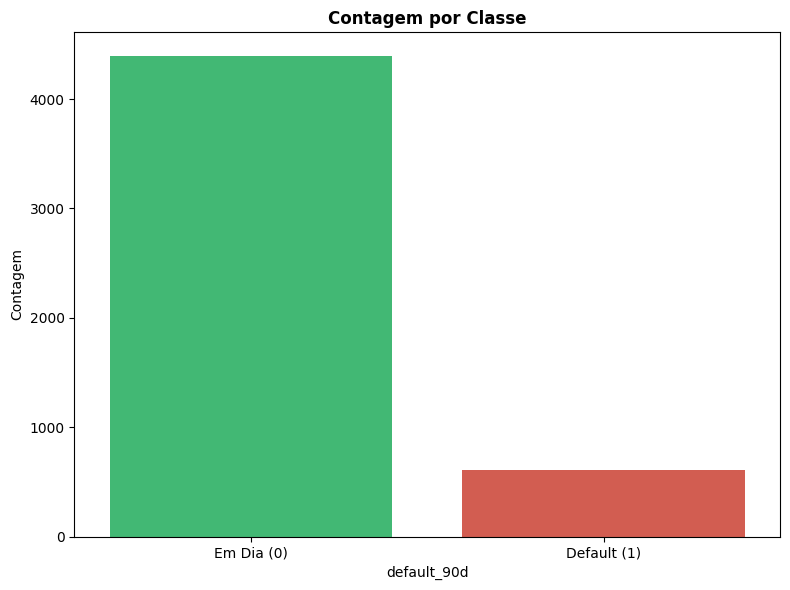

In [80]:

plt.figure(figsize=(8, 6))
sns.barplot(x=contagem_target.index, y=contagem_target.values,
            palette=['#2ecc71', '#e74c3c'], hue=contagem_target.index, legend=False)
plt.title('Contagem por Classe', fontweight='bold')
plt.xlabel('default_90d')
plt.ylabel('Contagem')
plt.xticks([0, 1], ['Em Dia (0)', 'Default (1)'], rotation=0)

plt.tight_layout()
plt.show()

In [81]:
remover_coluna = ['id_cliente', 'status_apos_90d', 'atraso_primeira_parcela_dias', 'parcelas_pagas_ate_3m']

df_tratado  = df.drop(remover_coluna, axis=1)
df_tratado.head()

,idade,renda_mensal,tempo_emprego_anos,autonomo,score_credito,valor_solicitado,prazo_meses,juros_mensal_pct,qtde_cartoes,qtde_contratos_abertos,utilizacao_credito,inadimplencias_anteriores,dias_atraso_max_12m,reclamacoes_6m,possui_avalista,canal_aquisicao,regiao,tipo_produto,default_90d
0,22,2639.75,2.718888,0,617.0,2619.14,12,3.96,3,0,0.012,1,0,0,0,site,Sul,emprestimo_pessoal,1
1,59,2482.34,10.785992,0,619.0,9101.21,36,3.37,2,2,0.282,1,0,0,0,app,Sudeste,cartao,0
2,52,6230.69,9.547608,0,665.0,13258.67,48,3.12,0,2,0.120,0,0,0,0,loja,Sudeste,cartao,0
3,41,6469.45,4.287084,0,676.0,1407.28,12,1.52,2,3,0.670,0,90,1,0,parceiro,Sudeste,emprestimo_pessoal,0
4,40,2343.04,0.000000,0,671.0,2647.92,48,3.07,1,0,0.325,0,15,0,0,app,Nordeste,bnpl,0


In [82]:
x = df_tratado.drop('default_90d', axis=1)
y = df_tratado['default_90d']

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.20, random_state = 42, stratify = y)


print("x de treino: ", x_train.shape[0])
print("x de teste: ",x_test.shape[0])


x de treino:  4000
x de teste:  1000


In [83]:
colunas_numericas   = x.select_dtypes(include=['int64','float64']).columns.tolist()
colunas_categoricas = x.select_dtypes(include=['object']).columns.tolist()

print("Numéricas:", colunas_numericas)
print("Categóricas:", colunas_categoricas)


Numéricas: ['idade', 'renda_mensal', 'tempo_emprego_anos', 'autonomo', 'score_credito', 'valor_solicitado', 'prazo_meses', 'juros_mensal_pct', 'qtde_cartoes', 'qtde_contratos_abertos', 'utilizacao_credito', 'inadimplencias_anteriores', 'dias_atraso_max_12m', 'reclamacoes_6m', 'possui_avalista']
Categóricas: ['canal_aquisicao', 'regiao', 'tipo_produto']


In [84]:
pipeline_numerica = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  MinMaxScaler())
])



pipeline_categorica = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])


In [85]:
preprocessador = ColumnTransformer(transformers=[
    ('num', pipeline_numerica,   colunas_numericas),
    ('cat', pipeline_categorica, colunas_categoricas)
])


In [86]:

x_train_proc = preprocessador.fit_transform(x_train)
x_test_proc  = preprocessador.transform(x_test)


In [87]:
# Cross-validation com 5 folds estratificados
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Os 3 modelos — cada um dentro de uma Pipeline completa
modelos = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'CatBoost':            CatBoostClassifier(iterations=200, random_seed=42, verbose=0)
}

resultados = {}

print("🔄 Comparando modelos com 5-Fold CV...\n")

for nome, modelo in modelos.items():
    pipeline_modelo = Pipeline(steps=[
        ('prep',  preprocessador),
        ('model', modelo)
    ])

    scores = cross_validate(
        pipeline_modelo, x_train, y_train,
        cv=cv,
        scoring=['roc_auc', 'recall'],
    )

    resultados[nome] = {
        'AUC-ROC': scores['test_roc_auc'].mean(),
        'Recall':  scores['test_recall'].mean()
    }

    print(f"{nome}:")
    print(f"  AUC-ROC = {resultados[nome]['AUC-ROC']:.4f}")
    print(f"  Recall  = {resultados[nome]['Recall']:.4f}\n")

🔄 Comparando modelos com 5-Fold CV...

Logistic Regression:
  AUC-ROC = 0.7774
  Recall  = 0.1293

Random Forest:
  AUC-ROC = 0.7604
  Recall  = 0.0267

CatBoost:
  AUC-ROC = 0.7679
  Recall  = 0.1704



In [98]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

melhor_modelo = Pipeline(steps=[
    ('prep',  preprocessador),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])
melhor_modelo.fit(x_train, y_train)


# Predições no teste
y_pred      = melhor_modelo.predict(x_test)
y_pred_prob = melhor_modelo.predict_proba(x_test)[:, 1]

auc = roc_auc_score(y_test, y_pred_prob)

print(f"📊 AUC-ROC no Teste: {auc:.4f}")
print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Em Dia', 'Default']))

📊 AUC-ROC no Teste: 0.7133

📋 Classification Report:
              precision    recall  f1-score   support

      Em Dia       0.89      0.99      0.94       878
     Default       0.56      0.11      0.19       122

    accuracy                           0.88      1000
   macro avg       0.72      0.55      0.56      1000
weighted avg       0.85      0.88      0.84      1000



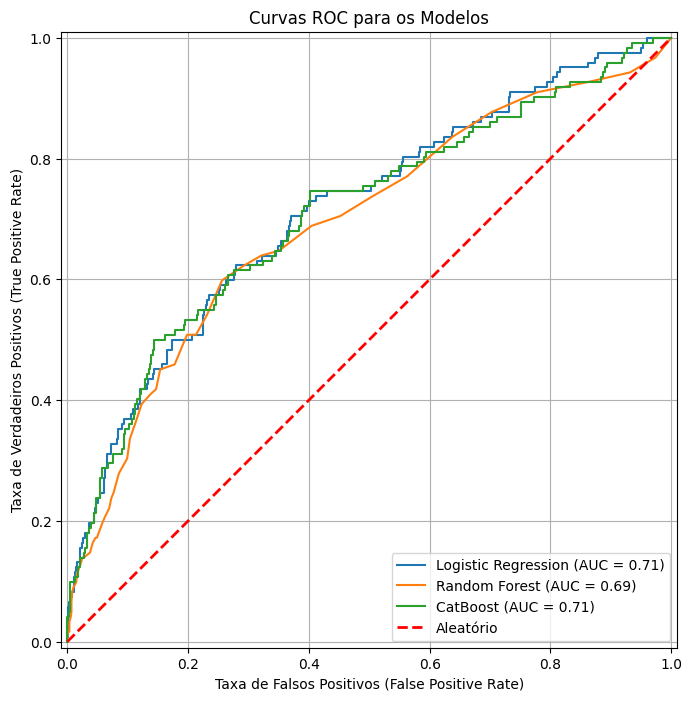

In [96]:
plt.figure(figsize=(10, 8))


for nome, modelo in modelos.items():
    pipeline_modelo = Pipeline(steps=[
        ('prep',  preprocessador),
        ('model', modelo)
    ])


    pipeline_modelo.fit(x_train, y_train)


    RocCurveDisplay.from_estimator(
        pipeline_modelo, x_test, y_test,
        name=nome,
        ax=plt.gca()
    )

plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Aleatório')
plt.title('Curvas ROC para os Modelos')
plt.xlabel('Taxa de Falsos Positivos (False Positive Rate)')
plt.ylabel('Taxa de Verdadeiros Positivos (True Positive Rate)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()